# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [3]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


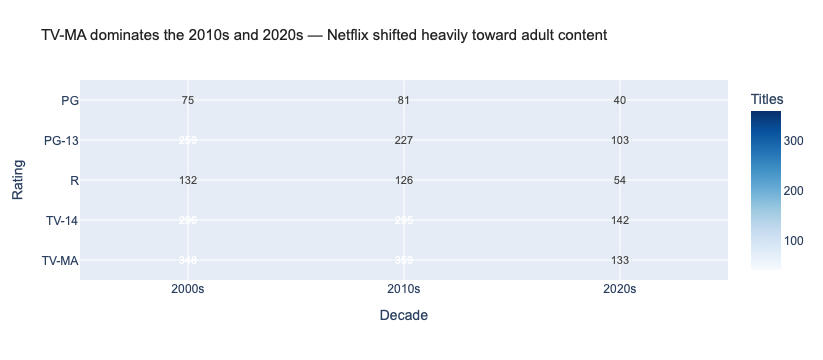

In [4]:
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

ratings = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']
filtered = df[df['rating'].isin(ratings)]

pivot = (
    filtered.groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
    .pivot(index='rating', columns='decade', values='count')
    .fillna(0)
    .astype(int)
)

fig = px.imshow(
    pivot,
    text_auto=True,
    color_continuous_scale='Blues',
    aspect='auto',
    labels=dict(x='Decade', y='Rating', color='Titles')
)

fig.update_traces(
    textfont=dict(family='Arial', size=11)
)

fig.update_layout(
    title=dict(
        text="TV-MA dominates the 2010s and 2020s — Netflix shifted heavily toward adult content",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(side='bottom'),
    coloraxis_showscale=True,
    margin=dict(t=80)
)

fig.show()


## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


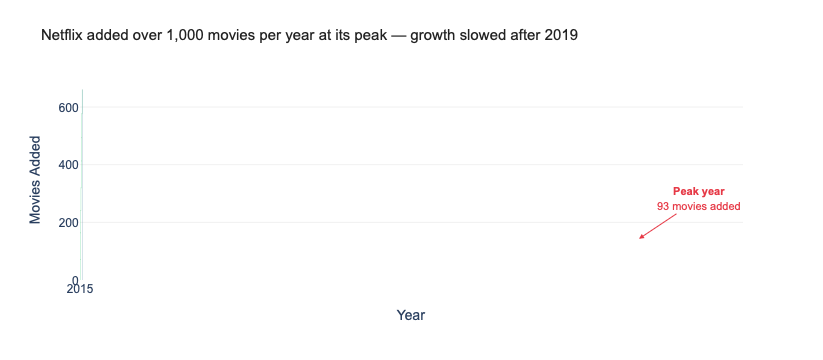

In [6]:
movies = df[(df['type'] == 'Movie') & 
            (df['added_year'].between(2015, 2022))]

yearly = (
    movies.groupby('added_year')
    .size()
    .reset_index(name='count')
    .sort_values('added_year')
)

peak_year = yearly.loc[yearly['count'].idxmax(), 'added_year']
peak_count = yearly.loc[yearly['count'].idxmax(), 'count']
total = yearly['count'].sum()

years = [str(y) for y in yearly['added_year'].tolist()] + ['Total']
values = yearly['count'].tolist() + [total]
measures = ['relative'] * len(yearly) + ['total']

fig = go.Figure(go.Waterfall(
    x=years,
    y=values,
    measure=measures,
    increasing=dict(marker=dict(color='#2ECC71')),
    decreasing=dict(marker=dict(color='#E63946')),
    totals=dict(marker=dict(color='#457B9D')),
    textposition='outside',
    text=[f"+{v}" if m == 'relative' else str(v)
          for v, m in zip(values, measures)],
    textfont=dict(family='Arial', size=11),
    connector=dict(line=dict(color='#CCCCCC', width=1))
))

fig.add_annotation(
    x=str(peak_year),
    y=peak_count + 50,
    text=f"<b>Peak year</b><br>{peak_count} movies added",
    showarrow=True,
    arrowhead=2,
    arrowcolor='#E63946',
    ax=60, ay=-40,
    font=dict(family='Arial', size=11, color='#E63946')
)

fig.update_layout(
    title=dict(
        text="Netflix added over 1,000 movies per year at its peak — growth slowed after 2019",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(showgrid=False, showline=False, title='Year'),
    yaxis=dict(showgrid=True, gridcolor='#F0F0F0', showline=False, title='Movies Added'),
    showlegend=False,
    margin=dict(t=80)
)

fig.show()